In [1]:
#Online Shopping Purchase Prediction

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("online_shopping.csv")
data

,Age,Gender,Time_Spent_Minutes,Pages_Viewed,Previous_Purchases,Purchased
0,27,Female,7,12,2,0
1,54,Female,6,10,8,0
2,33,Male,54,19,9,0
3,18,Female,43,10,8,1
4,46,Male,56,18,0,0
...,...,...,...,...,...,...
95,33,Male,26,9,8,1
96,35,Male,14,17,9,0
97,43,Male,40,16,2,0
98,35,Male,40,4,0,1


In [4]:
# Convert categorical column (Gender) to numeric
data = pd.get_dummies(data, columns=['Gender'], drop_first=True)

In [5]:
#Q-1- Explore customer behavior

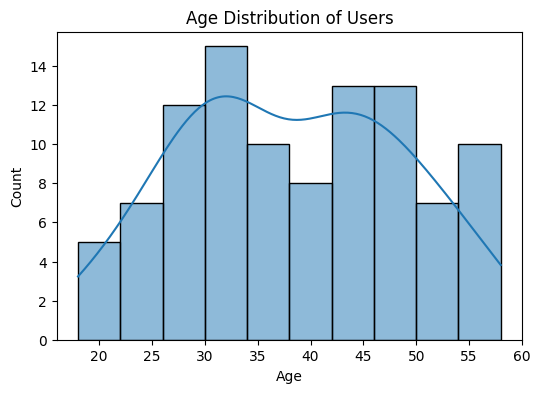

In [6]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(data['Age'], bins=10, kde=True)
plt.title("Age Distribution of Users")
plt.show()


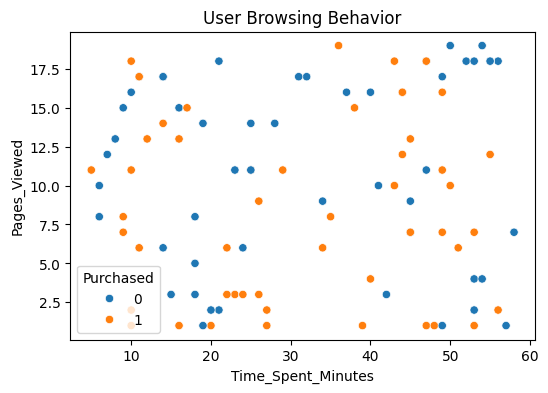

In [8]:
# Time Spent vs Purchase
plt.figure(figsize=(6,4))
sns.scatterplot(x='Time_Spent_Minutes', y='Pages_Viewed', hue='Purchased', data=data)
plt.title("User Browsing Behavior")
plt.show()

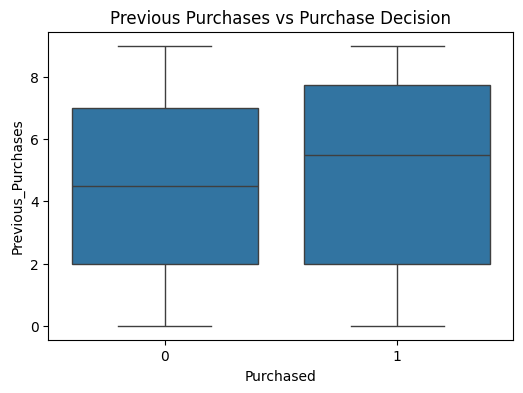

In [9]:
# Previous Purchases vs Purchased
plt.figure(figsize=(6,4))
sns.boxplot(x='Purchased', y='Previous_Purchases', data=data)
plt.title("Previous Purchases vs Purchase Decision")
plt.show()

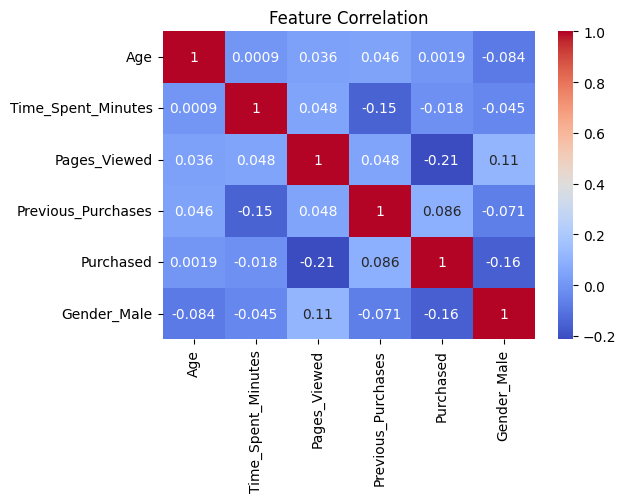

In [10]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [17]:
#Q-2-Train Logistic Regression model

In [18]:
# Features and target
X = data.drop('Purchased', axis=1)
y = data['Purchased']

In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
#Q-3-Predict purchase behavior
y_pred = model.predict(X_test)

In [15]:
#Q-4-Evaluate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.91      0.59      0.71        17
           1       0.22      0.67      0.33         3

    accuracy                           0.60        20
   macro avg       0.57      0.63      0.52        20
weighted avg       0.81      0.60      0.66        20

[[10  7]
 [ 1  2]]


In [16]:
# Predict purchase for a new user
sample = [[30, 5.5, 12, 3, 1]]  
prediction = model.predict(sample)

print("Prediction (1 = Will Purchase, 0 = Will Not Purchase):", prediction[0])

Prediction (1 = Will Purchase, 0 = Will Not Purchase): 0


C:\Users\Akrit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
